   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
(500000, 11)
<class 'pandas.DataFrame'>
Index: 500000 entries, 3737323 to 3264458
Data columns (total 11 

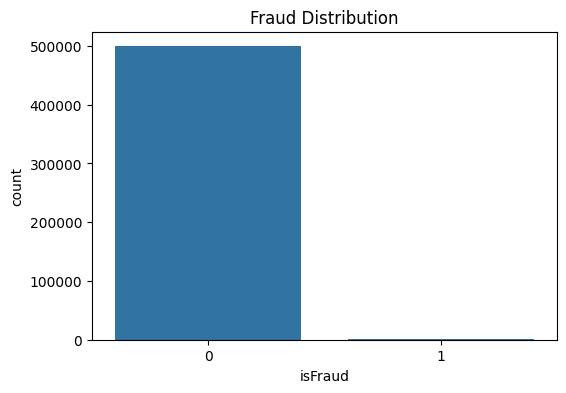

type
CASH_OUT    170164
PAYMENT     163903
CASH_IN     106306
TRANSFER     40602
DEBIT         3110
Name: count, dtype: int64


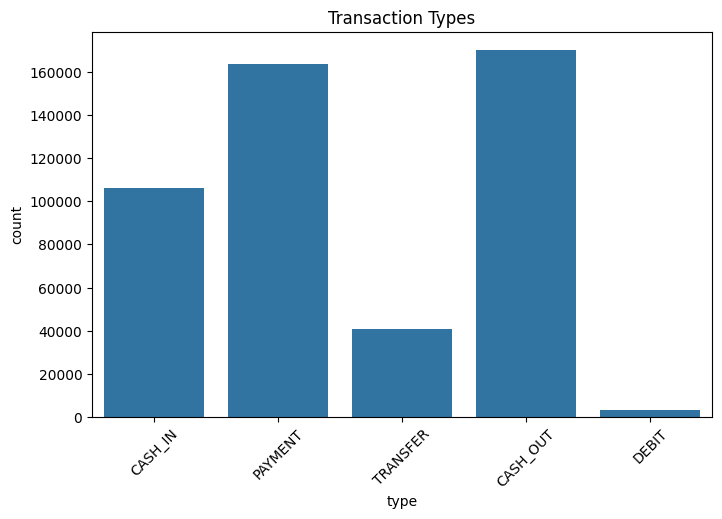

isFraud        0    1
type                 
CASH_IN   106306    0
CASH_OUT  169861  303
DEBIT       3110    0
PAYMENT   163903    0
TRANSFER   40282  320


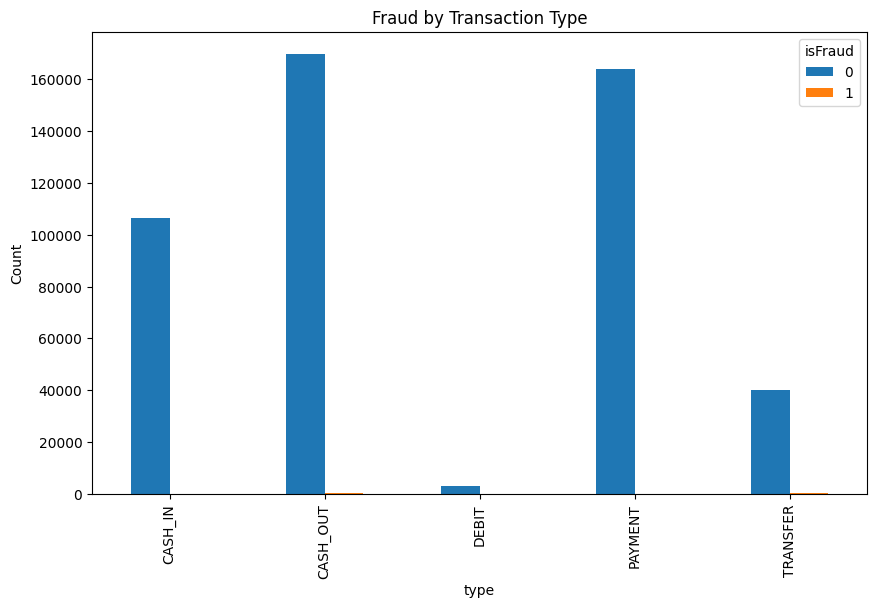

count    5.000000e+05
mean     1.806645e+05
std      6.053009e+05
min      0.000000e+00
25%      1.335691e+04
50%      7.493207e+04
75%      2.092577e+05
max      5.365362e+07
Name: amount, dtype: float64


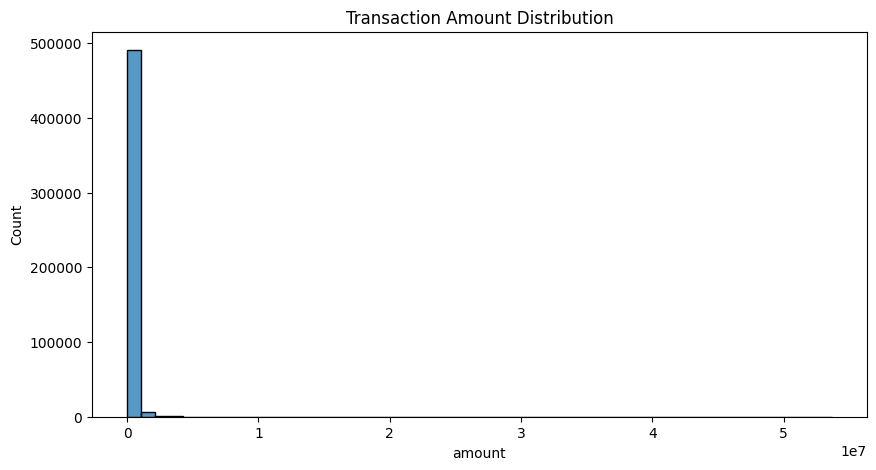

count    6.470000e+02
mean     1.341569e+06
std      2.222509e+06
min      0.000000e+00
25%      1.226750e+05
50%      4.482669e+05
75%      1.405454e+06
max      1.000000e+07
Name: amount, dtype: float64


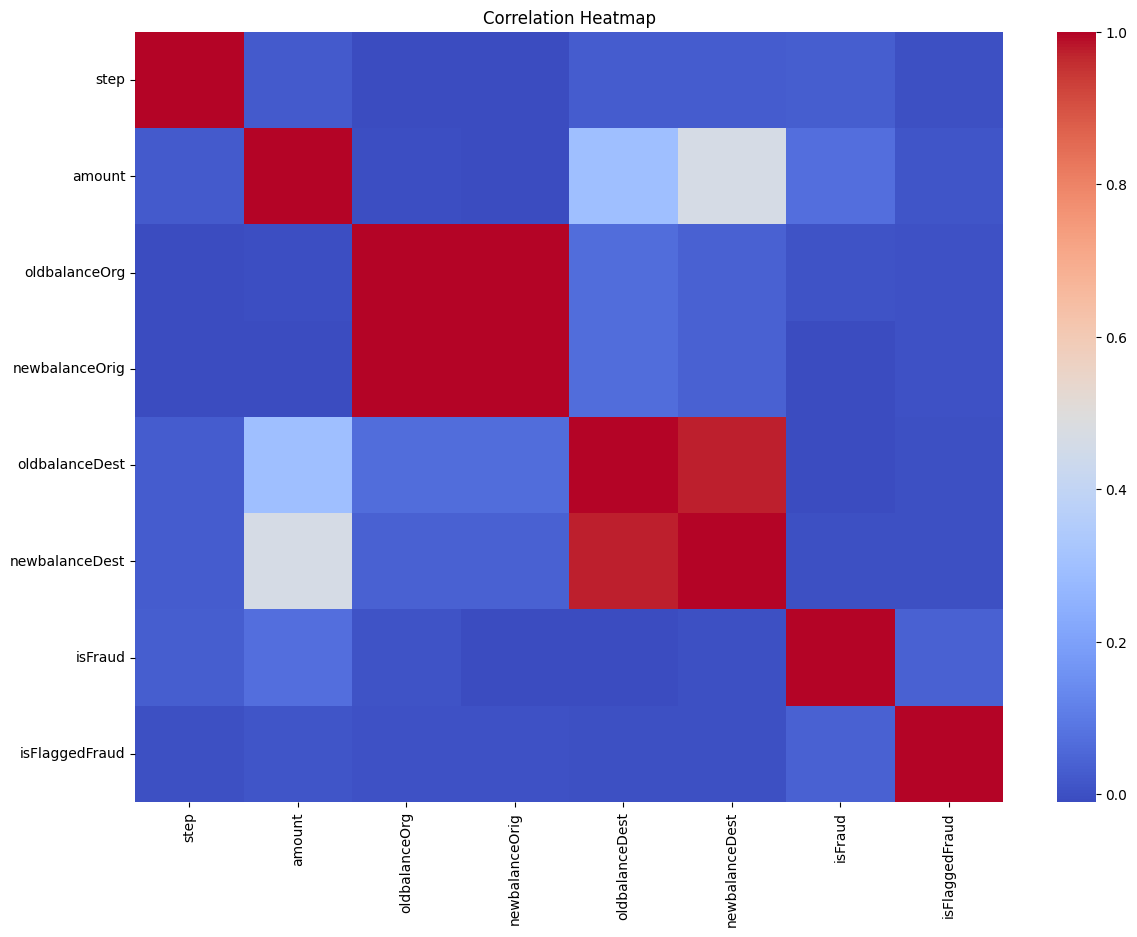

0
Sample dataset saved successfully


In [2]:
# ============================================
# STEP 1 - IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.close('all')


# ============================================
# STEP 2 - LOAD DATASET
# ============================================

df = pd.read_csv(
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\data\raw\fraud_detection.csv"
)

print(df.head())


# ============================================
# STEP 3 - CREATE SAMPLE DATA
# ============================================

df_sample = df.sample(500000, random_state=42)

print(df_sample.shape)


# ============================================
# STEP 4 - BASIC CHECKS
# ============================================

print(df_sample.info())

print(df_sample.describe())

print(df_sample.isnull().sum())


# ============================================
# STEP 5 - TARGET DISTRIBUTION
# ============================================

print(df_sample['isFraud'].value_counts())

fraud_percent = (
    df_sample['isFraud']
    .value_counts(normalize=True) * 100
)

print(fraud_percent)


# ============================================
# STEP 6 - VISUALIZE TARGET
# ============================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='isFraud',
    data=df_sample
)

plt.title("Fraud Distribution")

plt.show()


# ============================================
# STEP 7 - TRANSACTION TYPES
# ============================================

print(df_sample['type'].value_counts())

plt.figure(figsize=(8,5))

sns.countplot(
    x='type',
    data=df_sample
)

plt.title("Transaction Types")

plt.xticks(rotation=45)

plt.show()


# ============================================
# STEP 8 - FRAUD BY TYPE
# ============================================

fraud_by_type = pd.crosstab(
    df_sample['type'],
    df_sample['isFraud']
)

print(fraud_by_type)

fraud_by_type.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Fraud by Transaction Type")

plt.ylabel("Count")

plt.show()


# ============================================
# STEP 9 - AMOUNT DISTRIBUTION
# ============================================

print(df_sample['amount'].describe())

plt.figure(figsize=(10,5))

sns.histplot(
    df_sample['amount'],
    bins=50
)

plt.title("Transaction Amount Distribution")

plt.show()


# ============================================
# STEP 10 - FRAUD AMOUNT ANALYSIS
# ============================================

fraud_transactions = df_sample[
    df_sample['isFraud'] == 1
]

print(fraud_transactions['amount'].describe())


# ============================================
# STEP 11 - CORRELATION ANALYSIS
# ============================================

numeric_df = df_sample.select_dtypes(
    include=['number']
)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


# ============================================
# STEP 12 - DUPLICATE CHECK
# ============================================

print(df_sample.duplicated().sum())


# ============================================
# STEP 13 - SAVE SAMPLE DATA
# ============================================

df_sample.to_csv(
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\data\processed\fraud_sample.csv",
    index=False
)

print("Sample dataset saved successfully")